This file makes the variable selection figure for the Major Depression Disorder example.

In [12]:
%load_ext autoreload
%autoreload 2

import os

SELECTED_DEVICE = ''
print(f'Setting CUDA visible devices to [{SELECTED_DEVICE}]')
os.environ['CUDA_VISIBLE_DEVICES'] = f'{SELECTED_DEVICE}'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setting CUDA visible devices to []


In [13]:
import jax
jax.config.update("jax_enable_x64", True)  # Do we need this here? -> it seems we do for the LML computations (otherwise NaNs get introduced), but not for performance

import jax.random as jrnd
import jax.numpy as jnp
import distrax as dx
import blackjax
import pandas as pd
import time

import matplotlib.pyplot as plt

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

import sys

from blackjax.diagnostics import effective_sample_size, potential_scale_reduction

sys.path.append('/scratch/big/home/maxhin/Documents/Repos/bamojax/')

import bamojax
from bamojax.base import Model
from bamojax.sampling import gibbs_sampler, smc_inference_loop, mcmc_inference_loop
from bamojax.modified_blackjax.more_proposals import bernoulli_random_walk

print('Python version:       ', sys.version)
print('Jax version:          ', jax.__version__)
print('BlackJax version:     ', blackjax.__version__)
print('Distrax version:      ', dx.__version__)
print('BaMoJax version:      ', bamojax.__version__)
# print('Jax default backend:  ', jax.default_backend())
print('Jax devices:          ', jax.devices())

DATA_DIR = '/home/maxhin/Documents/Code/SMC tutorial/BLR/data/Request all'
RESULTS_DIR = '/home/maxhin/Documents/Code/SMC tutorial/BLR'
FIGURES_DIR = 'figures'

SMALL_SIZE = 14
MEDIUM_SIZE = 16
LARGE_SIZE = 22

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=LARGE_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=LARGE_SIZE)  # fontsize of the figure title

Python version:        3.10.15 (main, Oct  3 2024, 07:27:34) [GCC 11.2.0]
Jax version:           0.4.35
BlackJax version:      1.2.4
Distrax version:       0.1.5
BaMoJax version:       0.0.1
Jax devices:           [CpuDevice(id=0)]


Load NKI Rockland sample data

In [14]:
def read_data(add_intercept=False):
    filename = f'{DATA_DIR}/selected_variables_scaled.csv'
    df = pd.read_csv(filename, sep=',', header=[0]).drop(labels='ID', axis=1)
    data = jnp.asarray(df)
    X = data[:, 1:]        
    y = data[:, 0]
    labels = list(df.columns)
    labels.remove('DBDI_22')
    ix_age = labels.index('DEM_001')
    labels[ix_age] = 'Age'
    ix_gender = labels.index('DEM_002')
    labels[ix_gender] = 'Gender'   
    ix_nicotine = labels.index('FAGERADULT_9')
    labels[ix_nicotine] = 'Nicotine'   
    filename = f'{DATA_DIR}/DS_CODEBOOK.csv'
    df = pd.read_csv(filename, sep=',', header=[0])
    if add_intercept:
        X = jnp.column_stack((jnp.ones((X.shape[0], )), X))  # add intercept! -> note that it doesn't do anything...
        if labels != None:
            labels.insert(0, 'Intercept')
    return X, y, labels

#
X, y, labels = read_data(add_intercept=True)

Load results obtained with the `run_lncass_variable_selection.py` script.

In [ ]:
modes = ['MH', 'Gibbs', 'NUTS', 'MH-SMC', 'Gibbs-SMC', 'NUTS-SMC']

result_files = ['/scratch/big/home/maxhin/Documents/Repos/Introduction-to-SMC/Variable selection/Results/LNCASS_mh_MCMC.npy', 
                '/scratch/big/home/maxhin/Documents/Repos/Introduction-to-SMC/Variable selection/Results/LNCASS_gibbs_MCMC.npy',
                '/scratch/big/home/maxhin/Documents/Repos/Introduction-to-SMC/Variable selection/Results/LNCASS_nuts_MCMC.npy',
                '/scratch/big/home/maxhin/Documents/Repos/Introduction-to-SMC/Variable selection/Results/LNCASS_mh_SMC.npy',
                '/scratch/big/home/maxhin/Documents/Repos/Introduction-to-SMC/Variable selection/Results/LNCASS_gibbs_SMC.npy',
                '/scratch/big/home/maxhin/Documents/Repos/Introduction-to-SMC/Variable selection/Results/LNCASS_nuts_SMC.npy']

lncass_samples = []
times = []
num_adapt_cycles = []

M = len(result_files)

for file in result_files:
    results = jnp.load(file, allow_pickle=True).tolist()
    timing = results['times']
    if isinstance(timing, list):
        timing = timing[-1]
    times.append(timing)
    lncass_samples.append(results['states'])
    if 'num_smc_iter' in results.keys():
        if isinstance(results['num_smc_iter'], list):
            num_adapt_cycles.append(results['num_smc_iter'][-1])
        else:
            num_adapt_cycles.append(results['num_smc_iter'])

for mode, time in zip(modes, times):
    print(f'{mode}: {time} seconds')

MH: 5226.94273018837 seconds
Gibbs: 328.51293420791626 seconds
NUTS: 299.28806948661804 seconds
MH-SMC: 2654.396296262741 seconds
Gibbs-SMC: 45.26470327377319 seconds
NUTS-SMC: 335.7079427242279 seconds


Determine number of SMC cycles:

In [35]:
[jnp.mean(jnp.asarray(num_adapt)) for num_adapt in num_adapt_cycles]

[Array(47.25, dtype=float64),
 Array(51.75, dtype=float64),
 Array(47., dtype=float64)]

Compute effective sample sizes:

In [ ]:
samples_list = lncass_samples
samples_list_beta = [d['beta'] for d in samples_list]

samples_merged = jax.tree.map(lambda *l: jnp.stack(l), *samples_list_beta)
data = jax.tree.map(lambda l: jnp.reshape(l, shape=(M, 4*1000, -1)), samples_merged)

ess_all = []
ess_per_time = []

for m, method in enumerate(modes):
    print(method)
    ess = effective_sample_size(samples_list_beta[m], chain_axis=0, sample_axis=1)
    ess_all.append(ess)
    ess_per_time.append(ess / times[m])

stacked = jnp.stack(ess_all, axis=0)  
ess_interleaved = stacked.T.flatten()

stacked_ept = jnp.stack(ess_per_time, axis=0)
ept_interleaved = stacked_ept.T.flatten()

Visualize marginal posteriors of coefficients as box plot, effective sample sizes as bar plot, and wall-clock computation times as bar plots.

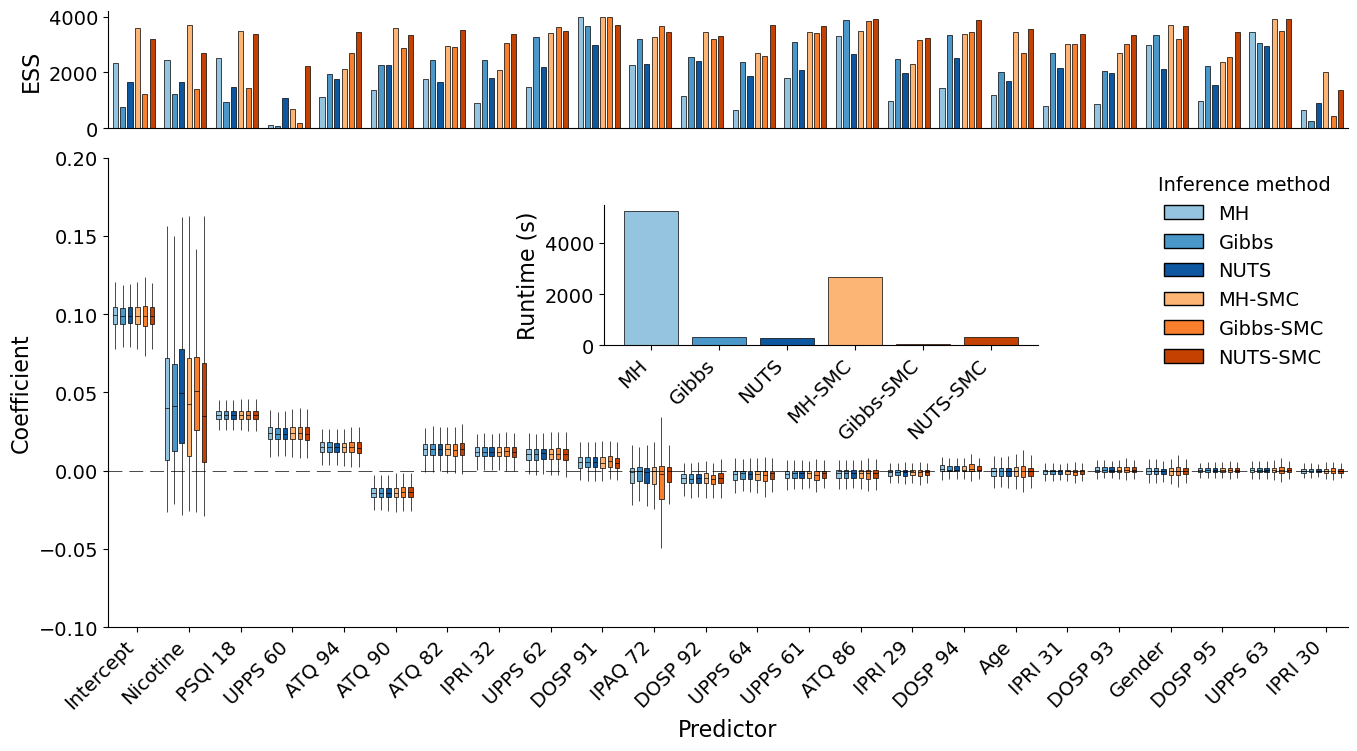

In [ ]:
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

_, _, labels = read_data(add_intercept=True)

ylabel = r'$\beta$'

# sort coefficients by magnitude
ix = jnp.argsort(jnp.abs(jnp.mean(data[2, :, :], axis=0)))[::-1]
data_sort = data[:, :, ix]

labels = [labels[i].replace('_', ' ') for i in ix]

M, _, p = data_sort.shape

group_width = M + 1  
positions = []
for group in range(p):
    start_pos = group * group_width
    positions.extend([start_pos + m for m in range(M)])

colors1 = plt.get_cmap('Blues')([0.4, 0.6, 0.85])
colors2 = plt.get_cmap('Oranges')([0.35, 0.55, 0.8])
colors = np.vstack((colors1, colors2))

fig = plt.figure(figsize=(16, 8))
gs = GridSpec(2, 1, height_ratios=[1, 4], hspace=0.1)

ax = fig.add_subplot(gs[1])

ax.axhline(y=0, ls=(0, (20, 10)), c='k', lw=0.5, zorder=9)

key = jrnd.PRNGKey(42)

for i in range(p):
    for m in range(M):
        pos = i * M + m
        ax.boxplot(data_sort[m, :, i], 
                    positions=[positions[pos]], 
                    widths=0.6, 
                    patch_artist=True,
                    boxprops=dict(facecolor=colors[m],
                                    linewidth=0.5),
                    showcaps=False,
                    medianprops=dict(color='k',
                                    linestyle='-',
                                    linewidth=0.5),
                    whiskerprops=dict(solid_capstyle='butt', 
                                        linewidth=0.5),
                    showfliers=False)        

legend_handles = [Patch(facecolor=colors[m], edgecolor='k', label=modes[m]) for m in range(M)]
ax.legend(handles=legend_handles, fontsize=SMALL_SIZE, edgecolor='w', facecolor='w', framealpha=1.0, title='Inference method')
ax.set_ylim([-0.1, 0.2])
ax.set_xlim([-1, positions[-1]+1])

ax.set_xticks(jnp.arange(p) * group_width + M/2)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_xlabel('Predictor', fontsize=MEDIUM_SIZE)
ax.set_ylabel('Coefficient', fontsize=MEDIUM_SIZE)

ax_in = ax.inset_axes([0.4, 0.6, 0.35, 0.3])
ax_in.bar(jnp.arange(M), times, color=colors, edgecolor='k', linewidth=0.5)

ax_in.set_xticks(jnp.arange(M), modes, rotation=45, ha='right')
ax_in.set_ylabel('Runtime (s)')

ax_ess = fig.add_subplot(gs[0])
ax_ess.bar(positions, ess_interleaved, edgecolor='k', linewidth=0.5, color=colors[jnp.arange(p*M) % M, ...], width=0.7)
ax_ess.set_xlim([-1, positions[-1]+1])
ax_ess.set_ylabel('ESS')
ax_ess.set_xticks([]);

for ax in [ax, ax_ess, ax_in]:
    ax.spines[['right', 'top']].set_visible(False)

Summarize ESS and ESS per time unit:

In [10]:
print('Mean effective sample size for regression coefficients beta')
for ess, method in zip(ess_all, modes):
    print(f'{method}: {jnp.mean(ess)}')

print('Mean effective sample size for regression coefficients beta, per second')
for m, ess, method in zip(jnp.arange(M), ess_all, modes):
    print(f'{method}: {jnp.mean(ess) / times[m]}')

Mean effective sample size for regression coefficients beta
MH: 1693.0813636124417
Gibbs: 2317.5829505970746
NUTS: 1990.097928113236
MH-SMC: 3035.7443778633265
Gibbs-SMC: 2712.0413806490333
NUTS-SMC: 3338.2280111413224
Mean effective sample size for regression coefficients beta, per second
MH: 0.32391427475070617
Gibbs: 7.054769262540736
NUTS: 6.649439556768629
MH-SMC: 1.1436665964827877
Gibbs-SMC: 59.915147664746016
NUTS-SMC: 9.943845784678254
